## Prediksi Kesehatan Mental Remaja: Segmentasi K-Means & Klasifikasi Logistic Regression vs Naïve Bayes

Notebook ini mengimplementasikan seluruh tahapan analisis pada **Bab IV** laporan, mengikuti
metodologi **CRISP-DM**. Urutan sel kode sengaja dibuat sejajar dengan sub-bab laporan
(4.1 s/d 4.9) agar setiap angka, tabel, dan gambar pada laporan dapat ditelusuri langsung
ke sel yang menghasilkannya.

In [1]:
# Import library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report, ConfusionMatrixDisplay, roc_curve)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("Library siap.")

Library siap.


## 4.1 Gambaran Umum Dataset

Dataset yang digunakan adalah **Teen Mental Health Dataset** (sumber: Kaggle), berisi
karakteristik kesehatan mental remaja dan perilaku penggunaan media sosial. Variabel yang
digunakan: *Age, Gender, Social Media Hours, Sleep Hours, Academic Performance, Physical
Activity, Stress Level, Anxiety Level, Social Interaction, Addiction Level,* dan
*Depression Label* (target).

In [2]:
df = pd.read_csv("Teen_Mental_Health_Dataset.csv")
TARGET = "depression_label"
print("Jumlah baris :", df.shape[0])
print("Jumlah kolom :", df.shape[1])
df.head()

Jumlah baris : 1200
Jumlah kolom : 13


,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0


## 4.2 Data Understanding
### 4.2.1 Struktur Dataset
Identifikasi jumlah data, nama atribut, dan tipe data — sumber **Tabel 4.1 Informasi Dataset**.

In [3]:
info = pd.DataFrame({
    "Kolom": df.columns,
    "Tipe Data": [str(t) for t in df.dtypes],
    "Non-Null": df.notnull().sum().values,
    "Jumlah Unik": [df[c].nunique() for c in df.columns],
})
print("Dimensi dataset:", df.shape)
info

Dimensi dataset: (1200, 13)


,Kolom,Tipe Data,Non-Null,Jumlah Unik
0,age,int64,1200,7
1,gender,object,1200,2
2,daily_social_media_hours,float64,1200,71
3,platform_usage,object,1200,3
4,sleep_hours,float64,1200,51
5,screen_time_before_sleep,float64,1200,26
6,academic_performance,float64,1200,201
7,physical_activity,float64,1200,21
8,social_interaction_level,object,1200,3
9,stress_level,int64,1200,10


### 4.2.2 Analisis Statistik Deskriptif
Sumber **Tabel 4.2 Statistik Deskriptif**.

In [4]:
desc = df.describe().T[["mean", "std", "min", "25%", "50%", "75%", "max"]].round(2)
desc

,mean,std,min,25%,50%,75%,max
age,15.93,2.02,13.0,14.0,16.00,18.00,19.0
daily_social_media_hours,4.54,2.03,1.0,2.8,4.50,6.30,8.0
sleep_hours,6.45,1.44,4.0,5.2,6.50,7.60,9.0
screen_time_before_sleep,1.74,0.72,0.5,1.1,1.80,2.40,3.0
academic_performance,2.99,0.58,2.0,2.5,2.99,3.48,4.0
physical_activity,1.01,0.58,0.0,0.5,1.00,1.50,2.0
stress_level,5.45,2.90,1.0,3.0,5.00,8.00,10.0
anxiety_level,5.64,2.86,1.0,3.0,6.00,8.00,10.0
addiction_level,5.56,2.83,1.0,3.0,6.00,8.00,10.0
depression_label,0.03,0.16,0.0,0.0,0.00,0.00,1.0


In [5]:
# Interpretasi otomatis (untuk narasi laporan)
print(f"Rata-rata penggunaan media sosial : {df['daily_social_media_hours'].mean():.2f} jam/hari")
print(f"Rata-rata jam tidur              : {df['sleep_hours'].mean():.2f} jam")
print(f"Rata-rata tingkat stres          : {df['stress_level'].mean():.2f} (skala 1-10)")
print(f"Rata-rata tingkat kecemasan      : {df['anxiety_level'].mean():.2f} (skala 1-10)")

Rata-rata penggunaan media sosial : 4.54 jam/hari
Rata-rata jam tidur              : 6.45 jam
Rata-rata tingkat stres          : 5.45 (skala 1-10)
Rata-rata tingkat kecemasan      : 5.64 (skala 1-10)


### 4.2.3 Visualisasi Data
Visualisasi: Distribusi Status Depresi (**Gambar 4.1**), Distribusi Penggunaan Media Sosial,
Distribusi Tingkat Stres, Distribusi Tingkat Kecemasan, dan Heatmap Korelasi (**Gambar 4.2**).

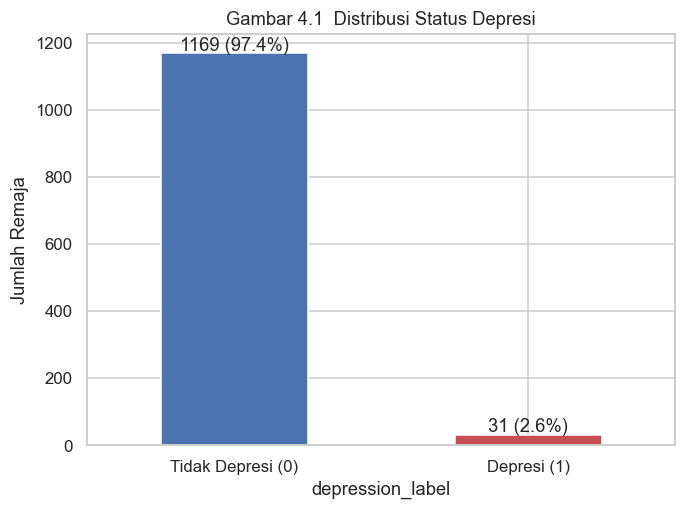

Kelas target sangat tidak seimbang (imbalanced).


In [6]:
# Gambar 4.1 - Distribusi Status Depresi
counts = df[TARGET].value_counts().sort_index()
ax = counts.plot(kind="bar", color=["#4C72B0", "#C44E52"])
ax.set_xticklabels(["Tidak Depresi (0)", "Depresi (1)"], rotation=0)
ax.set_title("Gambar 4.1  Distribusi Status Depresi")
ax.set_ylabel("Jumlah Remaja")
for i, v in enumerate(counts):
    ax.text(i, v + 8, f"{v} ({v/len(df)*100:.1f}%)", ha="center")
plt.tight_layout(); plt.show()
print("Kelas target sangat tidak seimbang (imbalanced).")

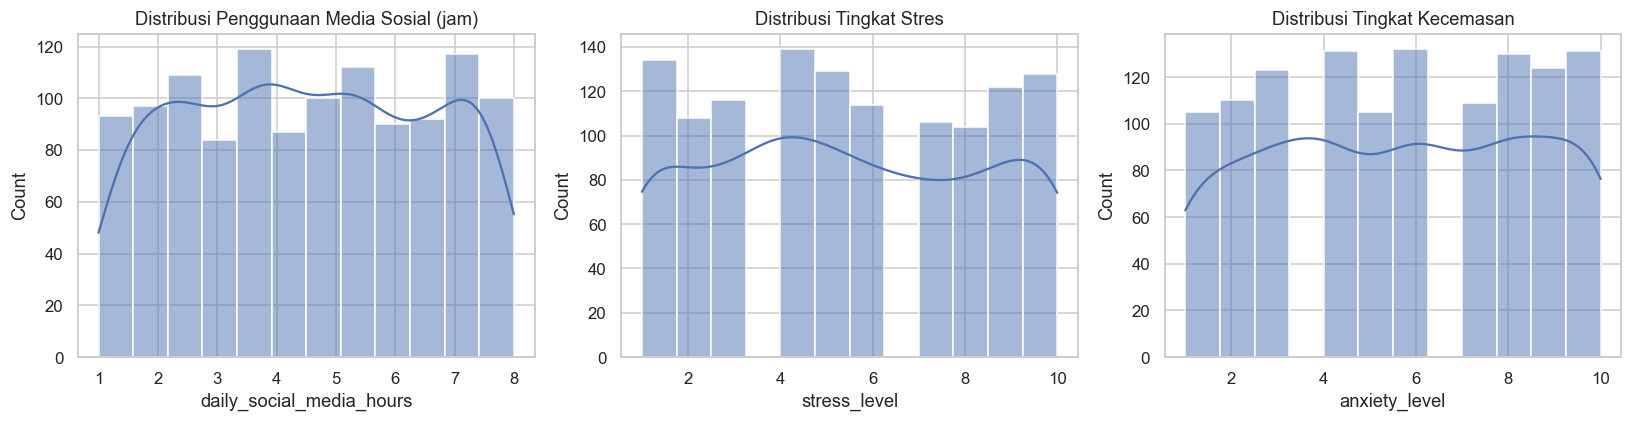

In [7]:
# Distribusi media sosial, stres, kecemasan
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, title in zip(
        axes,
        ["daily_social_media_hours", "stress_level", "anxiety_level"],
        ["Penggunaan Media Sosial (jam)", "Tingkat Stres", "Tingkat Kecemasan"]):
    sns.histplot(df[col], kde=True, ax=ax, color="#4C72B0")
    ax.set_title(f"Distribusi {title}")
plt.tight_layout(); plt.show()

In [8]:
# Gambar 4.2 - Correlation Heatmap (memakai data yang sudah di-encode di 4.3.3)
# (heatmap final ditampilkan setelah encoding agar variabel kategorikal ikut terhitung)

## 4.3 Data Preparation
### 4.3.1 Missing Value Handling — **Tabel 4.3**

In [9]:
missing = df.isnull().sum().to_frame("Jumlah Missing")
missing["Persentase (%)"] = (missing["Jumlah Missing"] / len(df) * 100).round(2)
print("Total missing value:", int(df.isnull().sum().sum()))
missing

Total missing value: 0


,Jumlah Missing,Persentase (%)
age,0,0.0
gender,0,0.0
daily_social_media_hours,0,0.0
platform_usage,0,0.0
sleep_hours,0,0.0
screen_time_before_sleep,0,0.0
academic_performance,0,0.0
physical_activity,0,0.0
social_interaction_level,0,0.0
stress_level,0,0.0


### 4.3.2 Remove Duplicate — **Tabel 4.4**

In [10]:
dup = int(df.duplicated().sum())
print("Jumlah data duplikat:", dup)
before = df.shape[0]
df = df.drop_duplicates().reset_index(drop=True)
print(f"Jumlah baris sebelum: {before}  ->  sesudah: {df.shape[0]}")

Jumlah data duplikat: 0
Jumlah baris sebelum: 1200  ->  sesudah: 1200


### 4.3.3 Label Encoding — **Tabel 4.5**
Variabel kategorikal (*gender, platform_usage, social_interaction_level*) ditransformasikan
menjadi numerik menggunakan **Label Encoding**.

In [11]:
df_enc = df.copy()
cat_cols = ["gender", "platform_usage", "social_interaction_level"]
mappings = {}
for c in cat_cols:
    le = LabelEncoder()
    df_enc[c] = le.fit_transform(df_enc[c])
    mappings[c] = dict(zip(le.classes_, le.transform(le.classes_)))
for c, m in mappings.items():
    print(f"{c:28s} -> {m}")
df_enc[cat_cols].head()

gender                       -> {'female': np.int64(0), 'male': np.int64(1)}
platform_usage               -> {'Both': np.int64(0), 'Instagram': np.int64(1), 'TikTok': np.int64(2)}
social_interaction_level     -> {'high': np.int64(0), 'low': np.int64(1), 'medium': np.int64(2)}


,gender,platform_usage,social_interaction_level
0,1,1,1
1,0,2,0
2,0,1,0
3,1,2,2
4,0,0,2


**Gambar 4.2 Correlation Heatmap** — hubungan antar variabel setelah encoding.

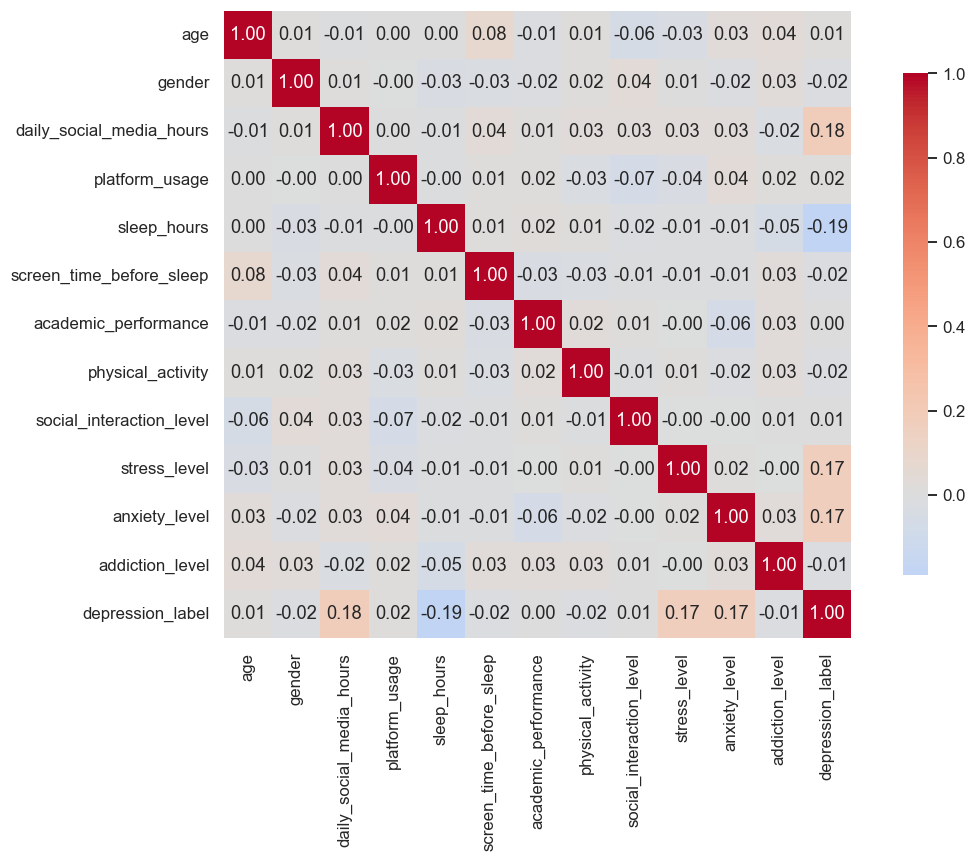

Korelasi tiap fitur terhadap depression_label:
daily_social_media_hours    0.175
stress_level                0.170
anxiety_level               0.170
platform_usage              0.018
age                         0.011
social_interaction_level    0.005
academic_performance        0.001
addiction_level            -0.014
screen_time_before_sleep   -0.017
physical_activity          -0.018
gender                     -0.020
sleep_hours                -0.191
Name: depression_label, dtype: float64


In [12]:
plt.figure(figsize=(11, 8))
sns.heatmap(df_enc.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, cbar_kws={"shrink": .8})
plt.tight_layout(); plt.show()

print("Korelasi tiap fitur terhadap depression_label:")
print(df_enc.corr()[TARGET].drop(TARGET).sort_values(ascending=False).round(3))

### 4.3.4 Feature Scaling
Penskalaan menggunakan **StandardScaler** agar tidak ada variabel yang mendominasi karena
rentang nilai yang besar. Hasil scaling dipakai untuk clustering dan klasifikasi.

In [13]:
X = df_enc.drop(columns=[TARGET])
y = df_enc[TARGET]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Bentuk X setelah scaling:", X_scaled.shape)
print("Mean ~0, Std ~1 (contoh kolom pertama): "
      f"mean={X_scaled[:,0].mean():.3f}, std={X_scaled[:,0].std():.3f}")

Bentuk X setelah scaling: (1200, 12)
Mean ~0, Std ~1 (contoh kolom pertama): mean=0.000, std=1.000


## 4.4 Hasil Clustering Menggunakan K-Means
### 4.4.1 Penentuan Jumlah Cluster — **Gambar 4.3 Elbow Method**

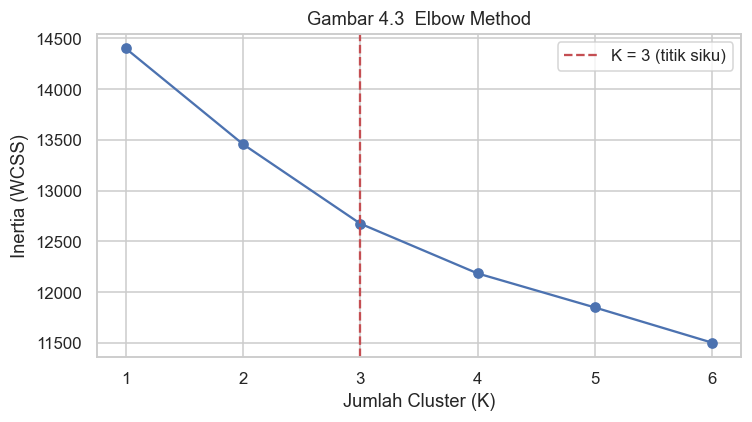

Penurunan inertia melandai setelah K=3 -> titik siku pada K=3.


In [14]:
inertias = []
K_range = range(1, 7)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(list(K_range), inertias, "o-", color="#4C72B0")
plt.axvline(3, color="#C44E52", ls="--", label="K = 3 (titik siku)")
plt.title("Gambar 4.3  Elbow Method")
plt.xlabel("Jumlah Cluster (K)"); plt.ylabel("Inertia (WCSS)")
plt.legend(); plt.tight_layout(); plt.show()
print("Penurunan inertia melandai setelah K=3 -> titik siku pada K=3.")

### 4.4.2 Silhouette Score — **Tabel 4.6**

In [15]:
sil_rows = []
for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit(X_scaled)
    sil_rows.append({"K": k, "Silhouette Score": round(silhouette_score(X_scaled, km.labels_), 4)})
sil_df = pd.DataFrame(sil_rows)
print(sil_df.to_string(index=False))
print("\nSelisih antar-K sangat kecil; K=3 dipilih karena konsisten dengan Elbow Method "
      "dan menghasilkan segmen yang paling mudah diinterpretasi (rendah/sedang/tinggi).")

 K  Silhouette Score
 2            0.0644
 3            0.0662
 4            0.0695
 5            0.0660
 6            0.0649

Selisih antar-K sangat kecil; K=3 dipilih karena konsisten dengan Elbow Method dan menghasilkan segmen yang paling mudah diinterpretasi (rendah/sedang/tinggi).


### 4.4.3 Karakteristik Cluster — **Tabel 4.7**
Model K-Means final dengan **K = 3**.

In [16]:
kmeans = KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init=10)
clusters = kmeans.fit_predict(X_scaled)
df["Cluster"] = clusters

profile_cols = ["age", "daily_social_media_hours", "sleep_hours", "screen_time_before_sleep",
                "physical_activity", "stress_level", "anxiety_level", "addiction_level"]
profile = df.groupby("Cluster")[profile_cols].mean().round(2)
profile["Jumlah Anggota"] = df["Cluster"].value_counts().sort_index().values
profile["Tingkat Depresi (%)"] = (df.groupby("Cluster")[TARGET].mean() * 100).round(1).values
profile.T

Cluster,0,1,2
age,17.24,14.66,15.90
daily_social_media_hours,4.17,4.93,4.52
sleep_hours,6.90,5.91,6.49
screen_time_before_sleep,1.99,1.45,1.76
physical_activity,1.12,0.93,1.00
stress_level,4.96,5.98,5.42
anxiety_level,5.45,5.73,5.69
addiction_level,5.68,5.61,5.48
Jumlah Anggota,310.00,308.00,582.00
Tingkat Depresi (%),1.00,3.60,2.90


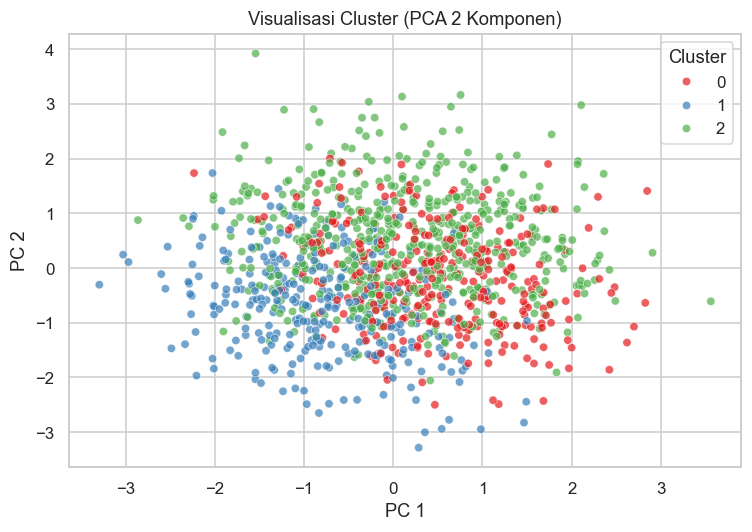

Interpretasi singkat tiap cluster:
  Cluster 0 (risiko RENDAH): medsos=4.17 jam, stres=4.96, tidur=6.90, depresi=1.0%
  Cluster 1 (risiko TINGGI): medsos=4.93 jam, stres=5.98, tidur=5.91, depresi=3.6%
  Cluster 2 (risiko SEDANG): medsos=4.52 jam, stres=5.42, tidur=6.49, depresi=2.9%


In [17]:
# Visualisasi segmen dengan PCA 2D
pca = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca.fit_transform(X_scaled)
plt.figure(figsize=(7, 5))
sns.scatterplot(x=coords[:, 0], y=coords[:, 1], hue=df["Cluster"],
                palette="Set1", alpha=0.7, s=30)
plt.title("Visualisasi Cluster (PCA 2 Komponen)")
plt.xlabel("PC 1"); plt.ylabel("PC 2"); plt.legend(title="Cluster")
plt.tight_layout(); plt.show()

print("Interpretasi singkat tiap cluster:")
order = df.groupby("Cluster")["daily_social_media_hours"].mean().sort_values()
labels = {order.index[0]: "risiko RENDAH", order.index[1]: "risiko SEDANG", order.index[2]: "risiko TINGGI"}
for c in sorted(df["Cluster"].unique()):
    r = df[df["Cluster"] == c]
    print(f"  Cluster {c} ({labels[c]}): medsos={r['daily_social_media_hours'].mean():.2f} jam, "
          f"stres={r['stress_level'].mean():.2f}, tidur={r['sleep_hours'].mean():.2f}, "
          f"depresi={r[TARGET].mean()*100:.1f}%")

## 4.5 Hasil Klasifikasi Menggunakan Logistic Regression

Data dibagi menjadi **80% latih** dan **20% uji** dengan *stratified split* agar proporsi
kelas terjaga.

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
print("Data latih:", X_train.shape[0], "| Data uji:", X_test.shape[0])
print("Positif (depresi) -> latih:", int(y_train.sum()), "| uji:", int(y_test.sum()))

Data latih: 960 | Data uji: 240
Positif (depresi) -> latih: 25 | uji: 6


In [19]:
logreg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
logreg.fit(X_train, y_train)
pred_lr = logreg.predict(X_test)
proba_lr = logreg.predict_proba(X_test)[:, 1]

### 4.5.1 Confusion Matrix — **Gambar 4.4**

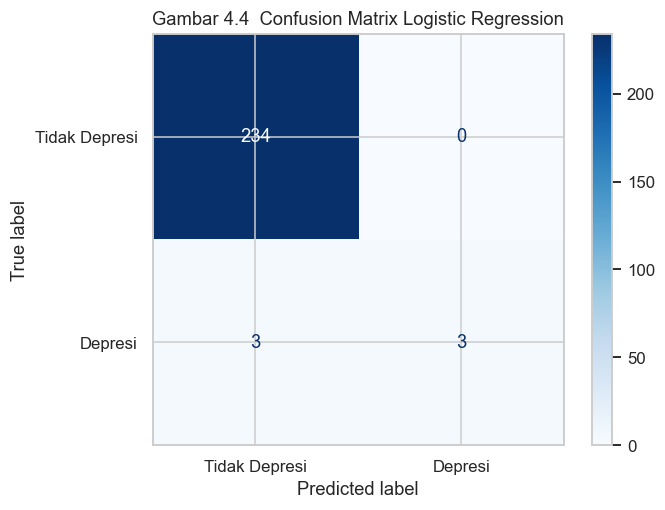

[[234   0]
 [  3   3]]


In [20]:
cm_lr = confusion_matrix(y_test, pred_lr)
ConfusionMatrixDisplay(cm_lr, display_labels=["Tidak Depresi", "Depresi"]).plot(cmap="Blues")
plt.title("Gambar 4.4  Confusion Matrix Logistic Regression")
plt.tight_layout(); plt.show()
print(cm_lr)

### 4.5.2 Hasil Evaluasi — **Tabel 4.8**

In [21]:
def metric_row(name, y_true, y_pred, y_proba):
    return {
        "Model": name,
        "Accuracy": round(accuracy_score(y_true, y_pred), 4),
        "Precision": round(precision_score(y_true, y_pred, zero_division=0), 4),
        "Recall": round(recall_score(y_true, y_pred, zero_division=0), 4),
        "F1-Score": round(f1_score(y_true, y_pred, zero_division=0), 4),
        "ROC-AUC": round(roc_auc_score(y_true, y_proba), 4),
    }

eval_lr = metric_row("Logistic Regression", y_test, pred_lr, proba_lr)
print(classification_report(y_test, pred_lr, zero_division=0))
pd.DataFrame([eval_lr])

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       234
           1       1.00      0.50      0.67         6

    accuracy                           0.99       240
   macro avg       0.99      0.75      0.83       240
weighted avg       0.99      0.99      0.99       240



,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.9875,1.0,0.5,0.6667,0.995


## 4.6 Hasil Klasifikasi Menggunakan Naïve Bayes

In [22]:
nb = GaussianNB()
nb.fit(X_train, y_train)
pred_nb = nb.predict(X_test)
proba_nb = nb.predict_proba(X_test)[:, 1]

### 4.6.1 Confusion Matrix — **Gambar 4.5**

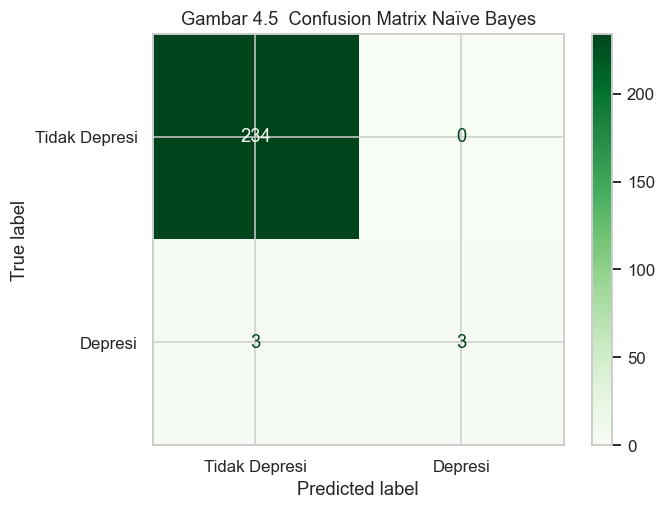

[[234   0]
 [  3   3]]


In [23]:
cm_nb = confusion_matrix(y_test, pred_nb)
ConfusionMatrixDisplay(cm_nb, display_labels=["Tidak Depresi", "Depresi"]).plot(cmap="Greens")
plt.title("Gambar 4.5  Confusion Matrix Naïve Bayes")
plt.tight_layout(); plt.show()
print(cm_nb)

### 4.6.2 Hasil Evaluasi — **Tabel 4.9**

In [24]:
eval_nb = metric_row("Naïve Bayes", y_test, pred_nb, proba_nb)
print(classification_report(y_test, pred_nb, zero_division=0))
pd.DataFrame([eval_nb])

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       234
           1       1.00      0.50      0.67         6

    accuracy                           0.99       240
   macro avg       0.99      0.75      0.83       240
weighted avg       0.99      0.99      0.99       240



,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Naïve Bayes,0.9875,1.0,0.5,0.6667,0.9986


## 4.7 Perbandingan Model — **Tabel 4.10**

In [25]:
comparison = pd.DataFrame([eval_lr, eval_nb]).set_index("Model")
best = comparison.sort_values(["F1-Score", "ROC-AUC"], ascending=False).index[0]
print(comparison.to_string())
print(f"\nModel terbaik: {best} "
      f"(F1-Score sama, ROC-AUC tertinggi = {comparison.loc[best,'ROC-AUC']}).")

                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Model                                                              
Logistic Regression    0.9875        1.0     0.5    0.6667   0.9950
Naïve Bayes            0.9875        1.0     0.5    0.6667   0.9986

Model terbaik: Naïve Bayes (F1-Score sama, ROC-AUC tertinggi = 0.9986).


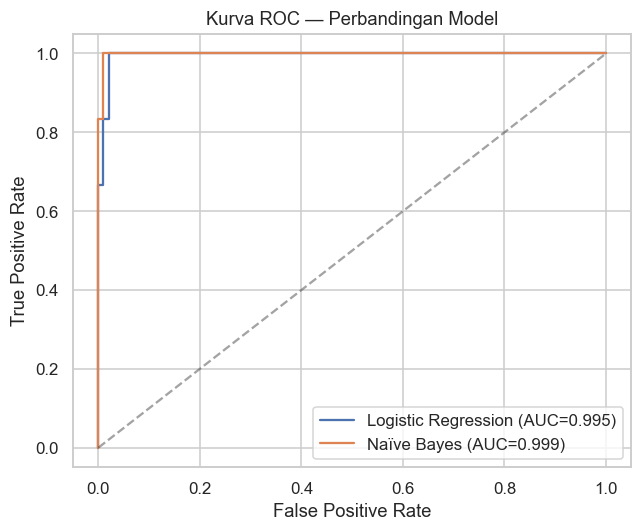

In [26]:
# Kurva ROC kedua model
plt.figure(figsize=(6, 5))
for name, proba in [("Logistic Regression", proba_lr), ("Naïve Bayes", proba_nb)]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, proba):.3f})")
plt.plot([0, 1], [0, 1], "k--", alpha=0.4)
plt.title("Kurva ROC — Perbandingan Model")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.legend(); plt.tight_layout(); plt.show()

## 4.8 Dashboard Streamlit

Tahap *deployment* memvisualisasikan hasil analisis melalui dashboard **Streamlit** yang
terdiri dari lima halaman utama:

1. **Gambaran Umum** — informasi dataset, statistik deskriptif
2. **Visualisasi EDA** — distribusi target, distribusi fitur numerik, heatmap korelasi
3. **Segmentasi K-Means** — elbow method, silhouette score, visualisasi PCA 2D, profil cluster
4. **Klasifikasi** — perbandingan Logistic Regression vs Naïve Bayes (confusion matrix, ROC, classification report)
5. **Prediksi Interaktif** — input manual data remaja lalu prediksi label depresi

Sel di bawah menyimpan artefak model ke folder models/. Dashboard dijalankan dengan:

`ash
streamlit run dashboard_streamlit.py
`

In [27]:
import joblib, os
os.makedirs("models", exist_ok=True)
joblib.dump(scaler, "models/scaler.pkl")
joblib.dump(kmeans, "models/kmeans.pkl")
joblib.dump(logreg, "models/logreg.pkl")
joblib.dump(nb, "models/naive_bayes.pkl")
comparison.to_csv("models/model_comparison.csv")
print("Artefak model tersimpan di folder models/ untuk dashboard Streamlit.")

Artefak model tersimpan di folder models/ untuk dashboard Streamlit.


## 4.9 Pembahasan

**Segmentasi (K-Means, K=3).** Remaja terbagi menjadi tiga segmen. Cluster dengan
penggunaan media sosial, stres, dan kecemasan tertinggi memiliki tingkat depresi paling
besar, sedangkan cluster dengan penggunaan rendah dan jam tidur lebih panjang memiliki
tingkat depresi terendah. Hal ini menegaskan keterkaitan antara perilaku digital dan
kondisi kesehatan mental.

**Klasifikasi.** Variabel dengan korelasi terkuat terhadap status depresi adalah
*durasi penggunaan media sosial*, *tingkat stres*, *tingkat kecemasan*, dan *jam tidur*
(berkorelasi negatif). Kedua model memberikan akurasi tinggi; berdasarkan ROC-AUC,
**Naïve Bayes** sedikit lebih unggul sehingga lebih direkomendasikan untuk kasus ini.

**Catatan keterbatasan.** Kelas target sangat tidak seimbang (±2,6% kasus depresi),
sehingga *accuracy* yang tinggi perlu dibaca bersama *recall* dan *F1-Score*. Hasil ini
bersifat analitis berbasis data, bukan untuk diagnosis klinis.

In [28]:
print("=== RINGKASAN HASIL BAB IV ===")
print(f"Dataset            : {df.shape[0]} baris, {df.shape[1]-1} kolom fitur + 1 target")
print(f"Missing / Duplikat : 0 / {dup}")
print(f"Distribusi target  : {int((y==0).sum())} tidak depresi, {int((y==1).sum())} depresi")
print(f"Jumlah cluster     : 3 (Elbow Method)")
print(f"Model terbaik      : {best}")
print(comparison.round(4).to_string())

=== RINGKASAN HASIL BAB IV ===
Dataset            : 1200 baris, 13 kolom fitur + 1 target
Missing / Duplikat : 0 / 0
Distribusi target  : 1169 tidak depresi, 31 depresi
Jumlah cluster     : 3 (Elbow Method)
Model terbaik      : Naïve Bayes
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Model                                                              
Logistic Regression    0.9875        1.0     0.5    0.6667   0.9950
Naïve Bayes            0.9875        1.0     0.5    0.6667   0.9986
